In [1]:
import numpy as np
import pandas as pd

# 1. VERİ SETİNİN YÜKLENMESİ
# CSV dosyasını Pandas DataFrame olarak yüklüyoruz (Dosya adını kendi dosya yoluna göre güncelleyebilirsin)
df = pd.read_csv("ibb_toplu_tasima_veri_seti.csv")

# 2. VERİ TİPİ DÖNÜŞTÜRMELERİ
# 'transition_date' sütununu daha rahat tarih analizleri yapabilmek için datetime formatına çeviriyoruz
df["transition_date"] = pd.to_datetime(df["transition_date"])

# 'transition_hour' sütununu sayısal analizler ve sıralamalar için tam sayı (integer) formatına dönüştürüyoruz
df["transition_hour"] = df["transition_hour"].astype(int)

# 3. EKSİK DEĞERLERİN (NaN) DOLDURULMASI
# 'number_of_passage' sütunundaki eksik (boş) verileri 0 değeri ile dolduruyoruz
df["number_of_passage"] = df["number_of_passage"].fillna(0)

# 'number_of_passenger' sütunundaki eksik (boş) verileri 0 değeri ile dolduruyoruz
df["number_of_passenger"] = df["number_of_passenger"].fillna(0)

# 4. IQR (INTERQUARTILE RANGE) YÖNTEMİ İLE UÇ DEĞERLERİN TEMİZLENMESİ
# Yolcu sayısı sütununun %25'lik birinci çeyreklik (Q1) değerini hesaplıyoruz
Q1 = df["number_of_passenger"].quantile(0.25)

# Yolcu sayısı sütununun %75'lik üçüncü çeyreklik (Q3) değerini hesaplıyoruz
Q3 = df["number_of_passenger"].quantile(0.75)

# Çeyrekler açıklığını (IQR), yani verinin merkezindeki %50'lik dilimin genişliğini buluyoruz
IQR = Q3 - Q1

# Uç değerleri belirlemek için alt sınır limitini hesaplıyoruz (Genel formül: Q1 - 1.5 * IQR)
alt_sinir = Q1 - 1.5 * IQR

# Uç değerleri belirlemek için üst sınır limitini hesaplıyoruz (Genel formül: Q3 + 1.5 * IQR)
ust_sinir = Q3 + 1.5 * IQR

# Belirlediğimiz alt ve üst sınırlar arasında kalan "normal" değerler için bir filtre (maske) oluşturuyoruz
filtre = (df["number_of_passenger"] >= alt_sinir) & (
    df["number_of_passenger"] <= ust_sinir
)

# Oluşturduğumuz filtreyi uygulayarak aşırı uç değerleri veri setimizden temizliyoruz
df_temiz = df[filtre]

In [ ]:
import pandas as pd

# 1. Adım: Orijinal devasa dosyayı yükle (Biraz sürebilir, arkana yaslan ve bekle)
# Dosya adını bilgisayarındaki orijinal isimle değiştirmeyi unutma!
buyuk_df = pd.read_csv('ibb_toplu_tasima.csv') 

# 2. Adım: Sadece ilk 10.000 satırı çek (Analiz ve modelleme için mükemmel bir örneklemdir)
kucuk_df = buyuk_df.head(10000)

# 3. Adım: Bunu GitHub'a yükleyeceğimiz 'veri.csv' olarak dışarı aktar
kucuk_df.to_csv('veri.csv', index=False)

print("İşlem tamam! 3 milyon satırlık veri, taptaze 10.000 satırlık 'veri.csv' dosyasına dönüştürüldü.")

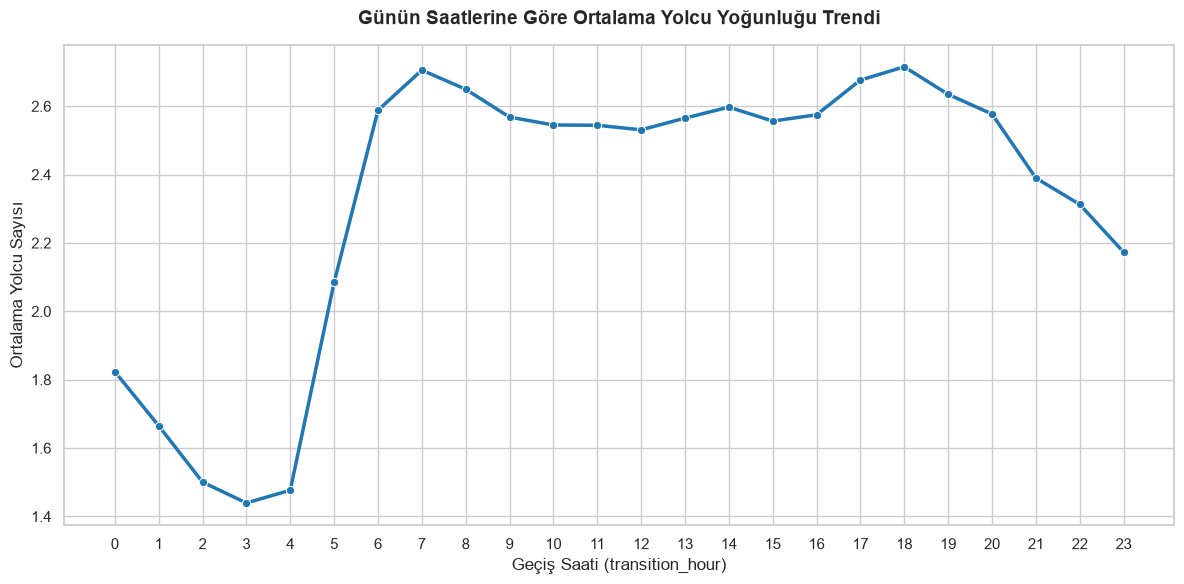

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Grafiğin arka plan stilini ve boyutunu ayarlıyoruz
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Saatlere göre gruplama yapıp toplam veya ortalama yolcu sayısını hesaplıyoruz
# Burada saatlik trendi net görmek için ortalama (mean) yolcu sayısını baz alıyoruz
saatlik_yolcu = (
    df_temiz.groupby("transition_hour")["number_of_passenger"]
    .mean()
    .reset_index()
)

# Çizgi grafiğini (Line Plot) çizdiriyoruz
sns.lineplot(
    data=saatlik_yolcu,
    x="transition_hour",
    y="number_of_passenger",
    marker="o",
    color="#1f77b4",
    linewidth=2.5,
)

# Grafik başlıklarını ve eksen isimlerini düzenliyoruz
plt.title(
    "Günün Saatlerine Göre Ortalama Yolcu Yoğunluğu Trendi",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Geçiş Saati (transition_hour)", fontsize=12)
plt.ylabel("Ortalama Yolcu Sayısı", fontsize=12)

# X eksenindeki saatlerin tamamının (0-23 arası) görünmesini sağlıyoruz
plt.xticks(range(0, 24))

# Grafiği ekranda gösteriyoruz
plt.tight_layout()
plt.show()

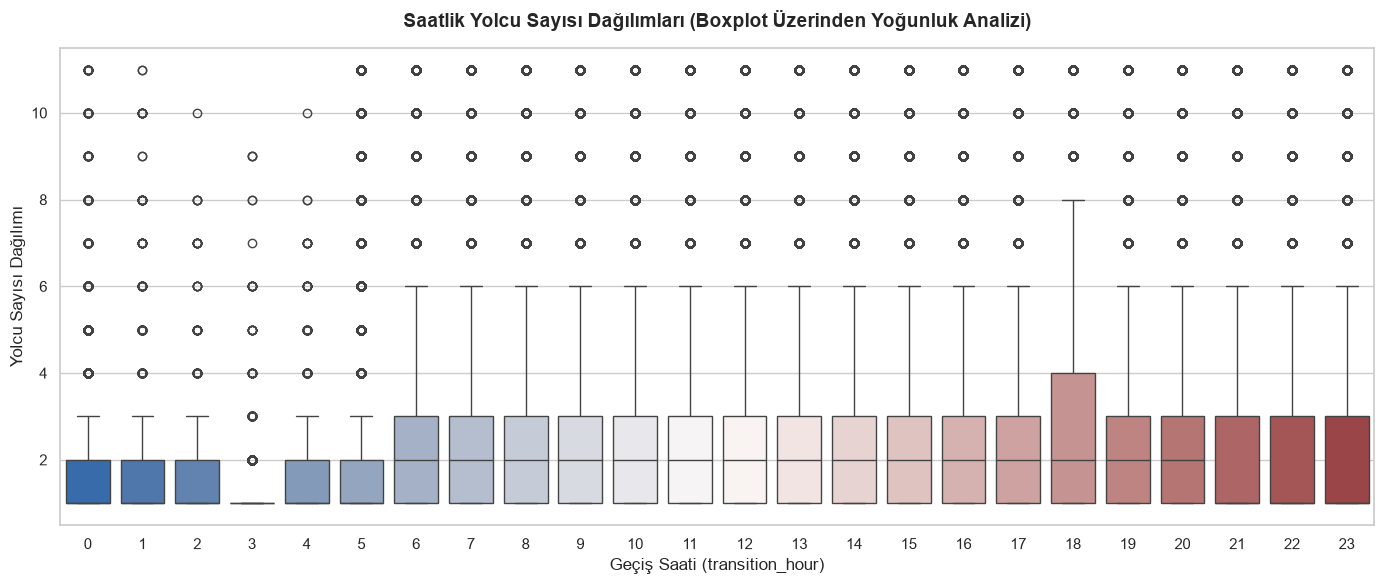

In [4]:
# Grafiğin boyutunu ayarlıyoruz
plt.figure(figsize=(14, 6))

# Her bir saat dilimi içindeki yolcu sayısı dağılımını Boxplot ile görselleştiriyoruz
# Bu grafik, zirve saatlerdeki varyasyonu ve yayılımı görmemizi sağlar
sns.boxplot(
    data=df_temiz,
    x="transition_hour",
    y="number_of_passenger",
    palette="vlag",
    hue="transition_hour",
    legend=False,
)

# Başlık ve eksen etiketlerini tanımlıyoruz
plt.title(
    "Saatlik Yolcu Sayısı Dağılımları (Boxplot Üzerinden Yoğunluk Analizi)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Geçiş Saati (transition_hour)", fontsize=12)
plt.ylabel("Yolcu Sayısı Dağılımı", fontsize=12)

# Grafiği ekranda gösteriyoruz
plt.tight_layout()
plt.show()

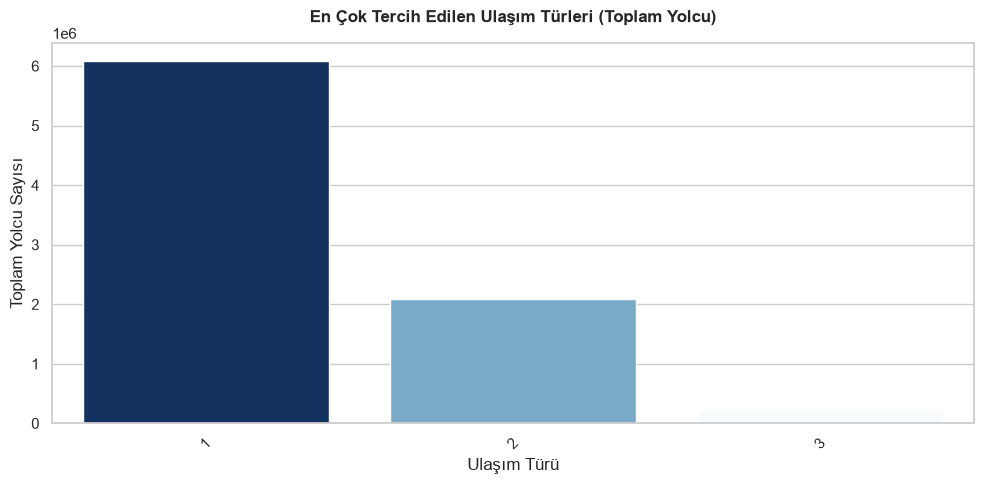

In [17]:
# Veri setinde 'transport_type' sütununun varlığını kontrol ediyoruz
if "transport_type_id" in df_temiz.columns:
    plt.figure(figsize=(10, 5))

    # Ulaşım türlerini toplam yolcu sayısına göre büyükten küçüğe sıralıyoruz
    ulasim_siralamasi = (
        df_temiz.groupby("transport_type_id")["number_of_passenger"]
        .sum()
        .sort_values(ascending=False)
        .index
    )

    # Seaborn Barplot güncellemesi: hem x hem hue kısmına aynı sütunu veriyoruz
    # Böylece hata vermeden renk paletini (palette) sorunsuz uygular
    sns.barplot(
        data=df_temiz,
        x="transport_type_id",
        y="number_of_passenger",
        estimator=sum,
        order=ulasim_siralamasi,
        hue="transport_type_id",  # Renklendirmenin hangi sütuna göre olacağını belirttik
        palette="Blues_r",  # Koyu maviden açığa doğru sıralar
        errorbar=None,  # Hata çubuklarını kaldırır
        legend=False,  # Ekstra gösterge kutusunu gizler
    )

    # Grafik başlık ve etiket ayarları
    plt.title(
        "En Çok Tercih Edilen Ulaşım Türleri (Toplam Yolcu)",
        fontweight="bold",
        pad=15,
    )
    plt.xlabel("Ulaşım Türü")
    plt.ylabel("Toplam Yolcu Sayısı")
    plt.xticks(rotation=45)  # İsimler uzunsa çakışmasın diye eğiyoruz

    plt.tight_layout()
    plt.show()
else:
    print(
        f"Veri setinde 'transport_type' bulunamadı. Mevcut sütunlar: {list(df_temiz.columns)}"
    )

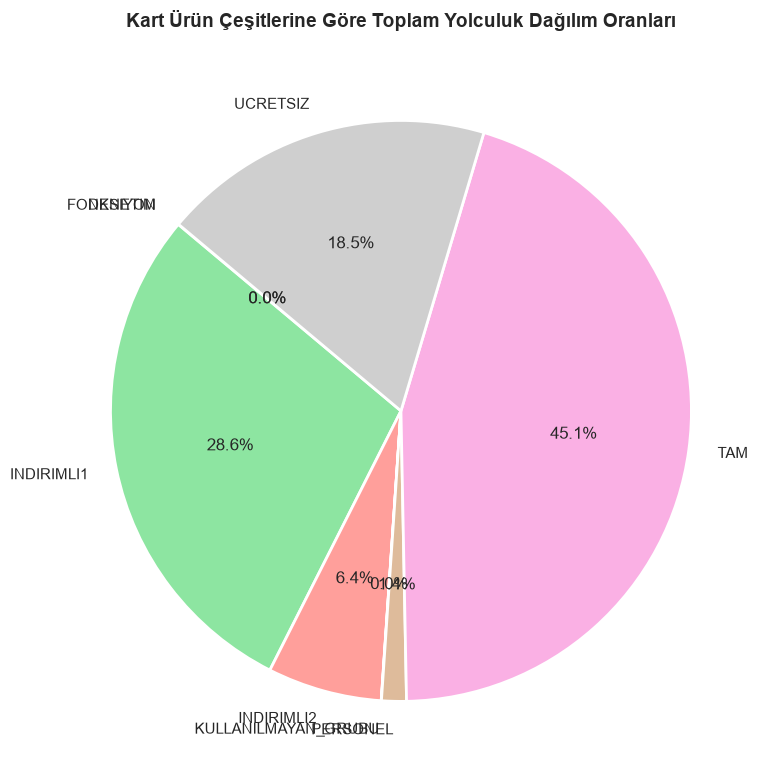

In [20]:
# Grafiğin boyutunu ayarlıyoruz
plt.figure(figsize=(8, 8))

# SÜTUN ADI GÜNCELLENDİ: "card_type" yerine senin verindeki "product_kind" sütununu kullanıyoruz
kart_dagilimi = (
    df_temiz.groupby("product_kind")["number_of_passenger"].sum().reset_index()
)

# Pasta grafiği için renk paleti belirliyoruz
renkler = sns.color_palette("pastel")[0 : len(kart_dagilimi)]

# Matplotlib kullanarak Pasta Grafiğini çizdiriyoruz
plt.pie(
    kart_dagilimi["number_of_passenger"],
    labels=kart_dagilimi["product_kind"],  # Burası da product_kind oldu
    autopct="%1.1f%%",  # Dilimlerin üzerine yüzde oranlarını yazdırır
    startangle=140,  # Grafik başlangıç açısı
    colors=renkler,
    wedgeprops={
        "edgecolor": "white",
        "linewidth": 2,
    },  # Dilimlerin arasına beyaz çizgi ekler
)

# Grafik başlığını ekliyoruz
plt.title(
    "Kart Ürün Çeşitlerine Göre Toplam Yolculuk Dağılım Oranları",
    fontsize=14,
    fontweight="bold",
    pad=15,
)

# Grafiği ekranda gösteriyoruz
plt.tight_layout()
plt.show()